## Predict if a patient is suffering from hearing disabilities

In [1]:
# import required packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

/home/sakshi/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
import warnings
warnings.filterwarnings(action="ignore")

In [3]:
df=pd.read_csv("hearing_test.csv")
df.head()

,age,physical_score,test_result
0,33.0,40.7,1
1,50.0,37.2,1
2,52.0,24.7,0
3,56.0,31.0,0
4,35.0,42.9,1


## EDA

In [4]:
df.describe()

,age,physical_score,test_result
count,5000.000000,5000.000000,5000.000000
mean,51.609000,32.760260,0.600000
std,11.287001,8.169802,0.489947
min,18.000000,-0.000000,0.000000
25%,43.000000,26.700000,0.000000
50%,51.000000,35.300000,1.000000
75%,60.000000,38.900000,1.000000
max,90.000000,50.000000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             5000 non-null   float64
 1   physical_score  5000 non-null   float64
 2   test_result     5000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 117.3 KB


In [7]:
df.isna().sum()

age               0
physical_score    0
test_result       0
dtype: int64

In [8]:
df.corr()

,age,physical_score,test_result
age,1.000000,-0.782146,-0.683171
physical_score,-0.782146,1.000000,0.792716
test_result,-0.683171,0.792716,1.000000


In [9]:
# create x
x=df.drop(['test_result'],axis=1)

#create y
y=df['test_result']

In [10]:
from sklearn.model_selection import train_test_split

# split the data as train and test
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=123456)

## Build the model

## Linear Regression

In [11]:
from sklearn.linear_model import LinearRegression

#create the model
model_linear = LinearRegression()

# train the model
model_linear.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Logistic Regression

In [13]:
from sklearn.linear_model import LogisticRegressionCV

# Create the model
model_logistic = LogisticRegressionCV()

# train the model
model_logistic.fit(x_train,y_train)

,Cs,10
,fit_intercept,True
,cv,None
,dual,False
,penalty,'l2'
,scoring,None
,solver,'lbfgs'
,tol,0.0001
,max_iter,100
,class_weight,None
,n_jobs,None


In [14]:
y_pred=model_logistic.predict(x_test)

In [15]:
y_pred

array([1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1,

## Evaluate the parameters(Evaluation matrix)

In [16]:
# confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
cm

array([[332,  61],
       [ 31, 576]])

In [18]:
from sklearn.metrics import accuracy_score

#accuracy of model

accuracy = accuracy_score(y_test,y_pred)
print(f"Accuracy = {accuracy * 100 :.2f}%")

Accuracy = 90.80%


In [19]:
from sklearn.metrics import precision_score

# precision

precision = precision_score(y_test,y_pred)
print(f"Precision = {precision * 100 :.2f}%")

Precision = 90.42%


In [20]:
from sklearn.metrics import recall_score

# recall
recall=recall_score(y_test,y_pred)
print(f"Recall = {recall * 100 :.2f}%")


Recall = 94.89%


In [21]:
from sklearn.metrics import f1_score

# f1

f1 = f1_score(y_test,y_pred)
print(f"F1 score = {f1 * 100 :.2f}%")

F1 score = 92.60%


## VIsualize the data

Text(0, 0.5, 'Physical_score')

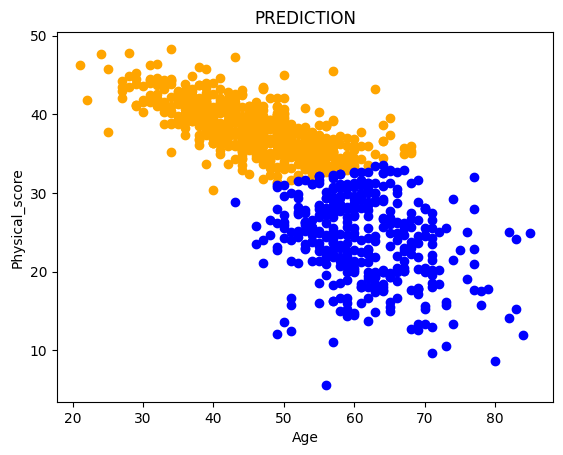

In [22]:
plt.scatter(x_test['age'][y_pred==1],x_test['physical_score'][y_pred==1],color="orange")
plt.scatter(x_test['age'][y_pred==0],x_test['physical_score'][y_pred==0],color="blue")

plt.title("PREDICTION")
plt.xlabel("Age")
plt.ylabel("Physical_score")


Text(0, 0.5, 'Physical_score')

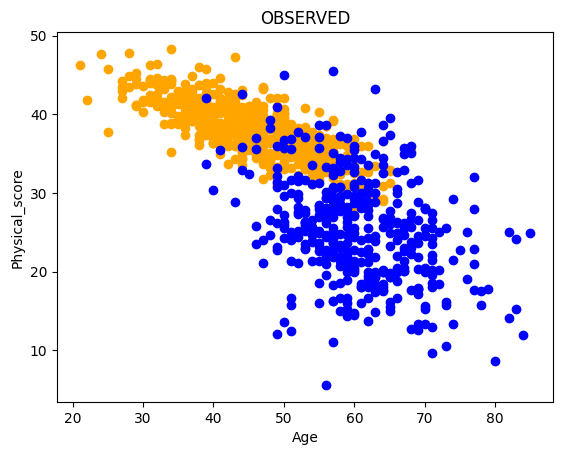

In [23]:
plt.scatter(x_test['age'][y_test==1],x_test['physical_score'][y_test==1],color="orange")
plt.scatter(x_test['age'][y_test==0],x_test['physical_score'][y_test==0],color="blue")

plt.title("OBSERVED")
plt.xlabel("Age")
plt.ylabel("Physical_score")